### Load and preview the dataset

In [48]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Load dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Preview first five rows of data
print(df.head())

# blank line
print()

# View structure of the dataframe
print(df.info())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

### Convert variables to "transactional" format

In [49]:
# Convert numeric features into binary (above/below median)
df_binary = df.apply(lambda x: x > x.median())

# Convert True/False to 1/0
df_binary = df_binary.astype(int)

print(df_binary.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0            1             0               1          1                1   
1            1             0               1          1                0   
2            1             1               1          1                1   
3            0             1               0          0                1   
4            1             0               1          1                1   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0                 1               1                    1              1   
1                 0               1                    1              1   
2                 1               1                    1              1   
3                 1               1                    1              1   
4                 1               1                    1              1   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

### Generate frequent itemsets

In [50]:
from mlxtend.frequent_patterns import apriori

# Keep itemsets that occur at least 30% of the time
frequent_itemsets = apriori(df_binary, min_support=0.3, use_colnames=True)

print(frequent_itemsets.head())

c:\Users\Raquel Mangual\AppData\Local\Programs\Python\Python314\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


    support                      itemsets
0  0.499121      frozenset({mean radius})
1  0.499121     frozenset({mean texture})
2  0.499121   frozenset({mean perimeter})
3  0.499121        frozenset({mean area})
4  0.499121  frozenset({mean smoothness})


### Generate the association rules

In [51]:
from mlxtend.frequent_patterns import association_rules

# Keep rules where at least 70% of "A" transactions also contain "B" (the "reliable" rules)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

                   antecedents                  consequents   support  \
0     frozenset({mean radius})  frozenset({mean perimeter})  0.488576   
1  frozenset({mean perimeter})     frozenset({mean radius})  0.488576   
2     frozenset({mean radius})       frozenset({mean area})  0.495606   
3       frozenset({mean area})     frozenset({mean radius})  0.495606   
4  frozenset({mean concavity})     frozenset({mean radius})  0.370826   

   confidence      lift  
0    0.978873  1.961193  
1    0.978873  1.961193  
2    0.992958  1.989412  
3    0.992958  1.989412  
4    0.742958  1.488532  


### Sort and output the association rules by lift value

In [52]:
rules_sorted = rules.sort_values(by='lift', ascending=False)

print(rules_sorted.head())

                                              antecedents  \
403353  frozenset({mean concavity, worst radius, area ...   
403262  frozenset({worst perimeter, area error, perime...   
278733  frozenset({mean concavity, worst radius, area ...   
403378  frozenset({worst area, mean concave points, ra...   
403288  frozenset({worst perimeter, worst area, mean c...   

                                              consequents  antecedent support  \
403353  frozenset({worst perimeter, worst area, mean c...            0.312830   
403262  frozenset({worst area, mean concave points, ra...            0.312830   
278733  frozenset({worst area, mean concave points, ra...            0.312830   
403378  frozenset({worst perimeter, area error, perime...            0.319859   
403288  frozenset({mean concavity, worst radius, area ...            0.319859   

        consequent support   support  confidence      lift  representativity  \
403353            0.319859  0.300527    0.960674  3.003426        

### Visualize the association rules

#### Graphs are always optional, but help to understand the analysis

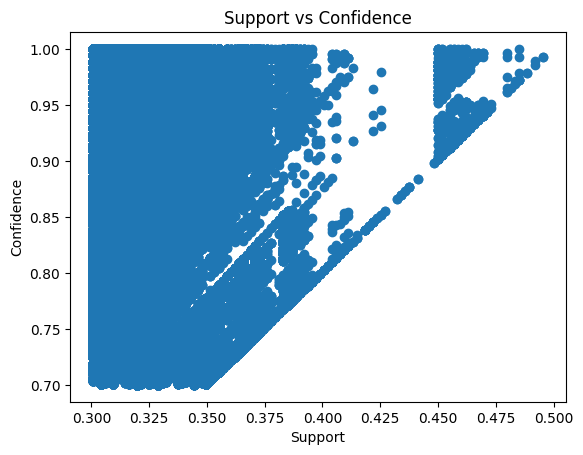

In [53]:
# Scatter plot
plt.figure()
plt.scatter(rules['support'], rules['confidence'])

# Labels
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')

plt.show()

### Scatter plot with emphasis on lift value

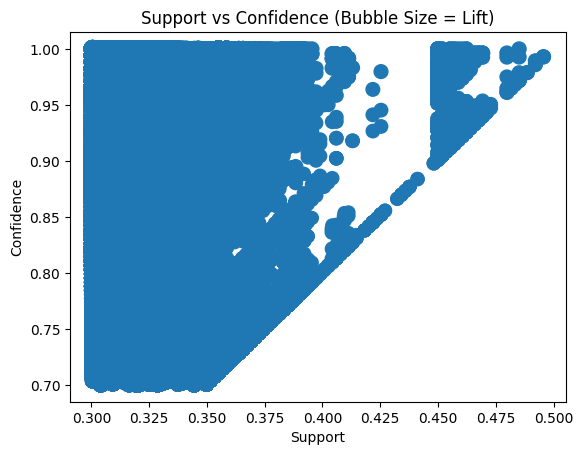

In [54]:
plt.figure()
plt.scatter(rules['support'], rules['confidence'], s=rules['lift']*50)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence (Bubble Size = Lift)')

plt.show()

### Network Graph

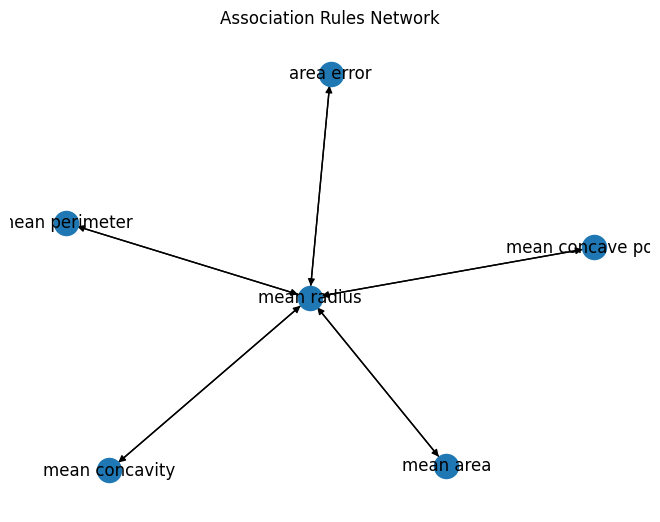

In [55]:
# Create graph
G = nx.DiGraph()

# Add edges (rules)
for _, row in rules.head(10).iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'])

# Draw graph
plt.figure()
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True)
plt.title("Association Rules Network")

plt.show()